# iredMUSE_LimMag

Original: pyetc_WST from Roland Bacon (WST) [git:pyetc_wst](https://github.com/ferromatteo/pyetc_wst)

Adapted: Nicolas Bouché (iredMUSE) [git:pyetc_iredmuse](https://github.com/nicolas-f-bouche/pyetc_iredmuse/)

This notebook shows how to:

- how to compute magnitude limits


The examples use the installed `pyetc_ifs` package [git:pyetc_iredmuse](https://github.com/nicolas-f-bouche/pyetc_iredmuse/) and static sky tables, so they do not require a SkyCalc network request.

In [1]:
%load_ext autoreload 
%autoreload 2

# 1. Imports

In [2]:

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from astropy.io import fits
from astropy.table import Table
import numpy as np
from datetime import datetime
from scipy.optimize import brentq
from tqdm.notebook import tqdm
import json, pickle
import os


## load pyetc_iredMUSE adnd define output path

In [144]:
from pyetc_iredmuse import ETC, iredMUSE, MUSE
from pyetc_iredmuse.etc import snr_in_window, plot_noise_components
from pyetc_iredmuse import get_seeing_fwhm, __version__

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 12,
})

path_to_images = "/home/nbouche/Python_git/pyetc_iredmuse/images/"
print(f"pyetc_ifs version {__version__}")

pyetc_ifs version 0.4


# 2. select instrument

In [147]:
muse=MUSE(log = 'INFO')
muse.info()

[INFO] Reading ifs full into self._transdata
[INFO] ETC version 0.4 release date 24 Sep 2026
[INFO] 	- Initial version
[INFO] Telescope Based on Prelim Concept version 26/06/2026
[INFO] Diameter: 8.00 m Eff. Area IFS: 48.5 m2
[INFO] IFS type IFS Channel full
[INFO] 	 Throughput model: Throughput estimations by Nicolas Bouché
[INFO] 	 Configuration version: 14/07/2026
[INFO] 	 Spaxel size: 0.20 arcsec Image Quality tel and ins fwhm: 0.10 and 0.13 arcsec beta: 2.80 
[INFO] 	 Wavelength range [4800. 9300.] A step 1.25 A LSF 2.2 pix Npix 3601
[INFO] 	 Instrument transmission peak 0.27 at 7060 - min 0.11 at 9300
[INFO] 	 Detector RON 2.6 e- Dark 3.0 e-/h


In [148]:
redmuse=iredMUSE(log = 'INFO')
redmuse.info()



[INFO] Reading ifs zband into self._transdata
[INFO] Reading ifs Jband into self._transdata
[INFO] Reading ifs zJband into self._transdata
[INFO] ETC version 0.4 release date 24 Sep 2026
[INFO] 	- cleaned up the code and added more documentation
[INFO] Telescope Based on Prelim Concept version 26/06/2026
[INFO] Diameter: 8.00 m Eff. Area IFS: 48.5 m2
[INFO] IFS type IFS Channel zband
[INFO] 	 Throughput model: Throughput estimations by Nicolas Bouché
[INFO] 	 Configuration version: 14/07/2026
[INFO] 	 Spaxel size: 0.22 arcsec Image Quality tel and ins fwhm: 0.10 and 0.13 arcsec beta: 2.80 
[INFO] 	 Wavelength range [ 9500. 11300.] A step 0.90 A LSF 2.2 pix Npix 2001
[INFO] 	 Instrument transmission peak 0.32 at 10667 - min 0.30 at 9500
[INFO] 	 Detector RON 6.0 e- Dark 72.0 e-/h
[INFO] IFS type IFS Channel Jband
[INFO] 	 Throughput model: Throughput estimations by Nicolas Bouché
[INFO] 	 Configuration version: 14/07/2026
[INFO] 	 Spaxel size: 0.22 arcsec Image Quality tel and ins fwhm:

In [149]:

instru=redmuse

#ifs_channels=np.array([instru.ifs['channels'][-1]])
ifs_channels=instru.ifs['channels']
ifs_channels

['zband', 'Jband', 'zJband']

In [150]:
def get_specinfo(full_obs, inst=instru):
    insfam = getattr(inst, full_obs["INS"])
    ins = insfam[full_obs["CH"]]
    lsf = ins['lsfpix']*ins['dlbda']
    dl = ins['dlbda']
    dr = full_obs['COADD_WL']*ins['dlbda']
    l1,l2 = ins['lbda1'],ins['lbda2']
    return dr,lsf,l1,l2,dl,ins

In [151]:
for ch in ifs_channels:
    ins=instru.ifs[ch]
    lstep_2 = ins['dlbda']
    print(ch, lstep_2)
    

zband 0.9
Jband 1.0
zJband 2.0


# 3. Show transmission

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_202690/2599633199.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda (\AA)$')


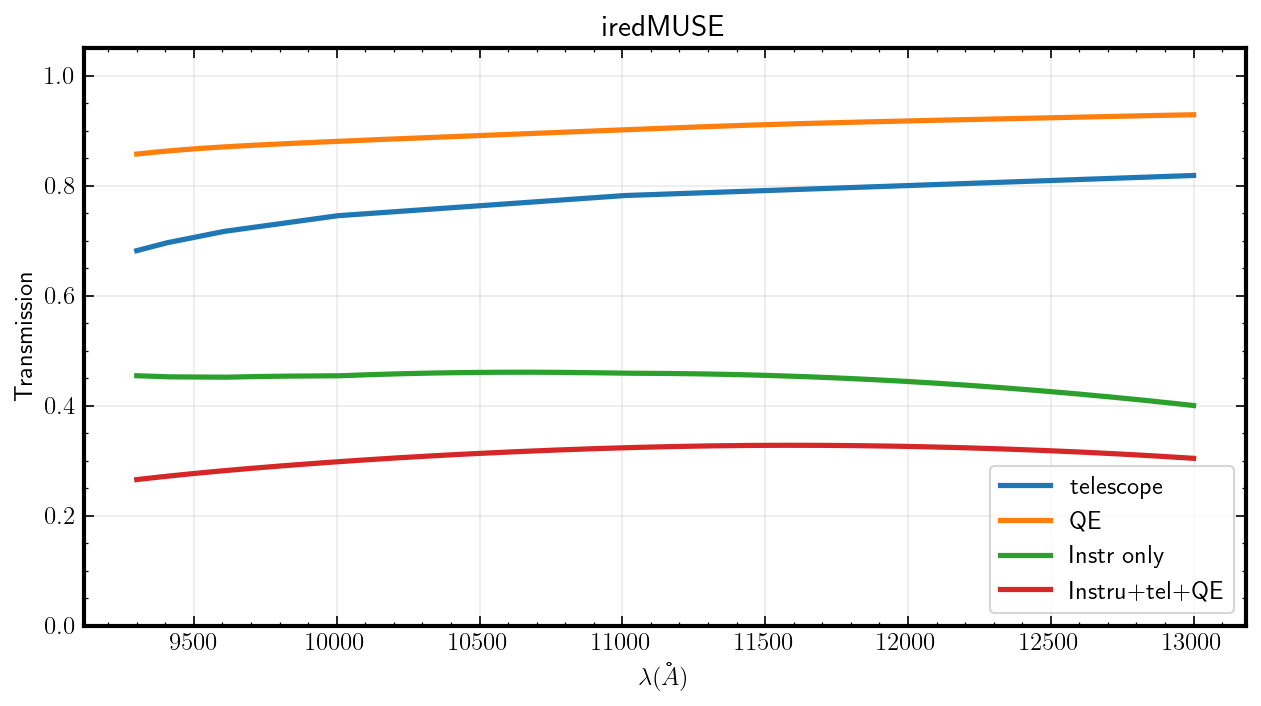

In [152]:
plt.plot(ins['wave'].coord(),ins['telescope'].data,label='telescope')
plt.plot(ins['wave'].coord(),ins['QE'].data,label='QE')
plt.plot(ins['wave'].coord(),ins['total_instrumental'].data,label='Instr only')
plt.plot(ins['wave'].coord(),ins['instrans'].data,label='Instru+tel+QE')
plt.ylim([0,1.05])
plt.ylabel('Transmission')
plt.xlabel('$\lambda (\AA)$')
plt.legend()
plt.title('{}'.format(instru.name))
plt.savefig(f'{path_to_images}/{instru.name}_transmission.png')

def optim_snr2(con, im, spe, lbda, coadd0, inst=instru):
    global niter
    snr1 = 0
    for coadd in np.arange(coadd0, 1, -1):
        niter += 1
        inst.obs['ima_coadd'] = coadd
        res_snr2 = inst.snr_at_wave(con, im, spe, wave_target=lbda)
        snr2 = res_snr2['snr_aperture']
        #print(coadd, snr2)
        if snr2 < snr1:
            break
        coadd1 = coadd
        snr1 = snr2
    for coadd in np.arange(coadd0+1, 20):
        niter += 1
        inst.obs['ima_coadd'] = coadd
        res_snr2 = inst.snr_at_wave(con, im, spe, wave_target=lbda)
        snr2 = res_snr2['snr_aperture']
        #print(coadd, snr2)
        if snr2 < snr1:
            break
        coadd1 = coadd
        snr1 = snr2
    return snr1,coadd1    

# 4. LSF

In [153]:
def lsf_resolution(wavelength_AA, ins=instru) -> float:
    """
    wavelength_AA : float | nd.array
    return the spectral resolution R = lambda / delta_lambda of the LSF at a given wavelength in Angstrom
    """

    lstep_AA = ins['dlbda']
    fwhm_AA = ins['lsfpix'] * lstep_AA

    return wavelength_AA / float(fwhm_AA)


In [154]:
for ch in ifs_channels:
    ins=instru.ifs[ch]
    lstep_AA = ins['wave'].get_step()
    fwhm_AA = ins['lsfpix'] * lstep_AA
    
    lmin,lmax=ins['wave'].get_range()

    lmean=(lmin+lmax)/2.0
    lstep_kms=lstep_AA/lmean*3e5
    fwhm_kms=fwhm_AA/lmean*3e5
    
    print("LSF Channel {} \n  step={:0.1f}AA ={:.0f}km/s \n  FWHM={:.2f}AA ={:.0f}km/s".format(ch,lstep_AA,lstep_kms,fwhm_AA,fwhm_kms))


LSF Channel zband 
  step=0.9AA =26km/s 
  FWHM=1.98AA =57km/s
LSF Channel Jband 
  step=1.0AA =25km/s 
  FWHM=2.20AA =54km/s
LSF Channel zJband 
  step=2.0AA =54km/s 
  FWHM=4.40AA =118km/s


In [155]:
for ch in ifs_channels:
    ins=instru.ifs[ch]
    l1,l2=ins['wave'].get_range()
    dl=ins['wave'].get_step()
    print(" {} ".format(ch),(l2-l1)/dl)

 zband  2000.0
 Jband  1700.0
 zJband  1850.0


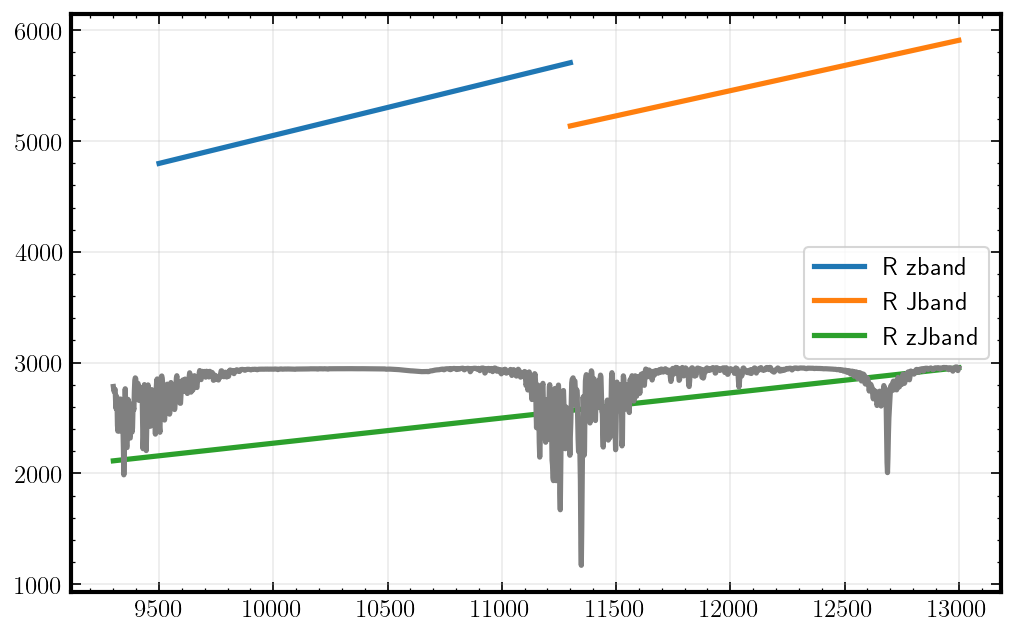

In [156]:
plt.figure(figsize=(8,5))
for ch in ifs_channels:
    ins=instru.ifs[ch]
    wave=ins['wave'].coord()
    R=lsf_resolution(wave, ins)
    plt.plot(wave,R,label='R {}'.format(ch))
plt.legend()
plt.plot(wave,ins['sky'][0]['abs'].data*3000,label='sky',c='grey')
plt.savefig(f"{path_to_images}/{instru.name}_resolution.png")

# 5. Select channel

In [163]:
ch='zJband'
ins=instru.ifs[ch]
ifs_channels=[ch]

# 6. Select Input Parameters

In [201]:
common_obs = {
    "NDIT": 3,
    "DIT": 1200,    
    "PWV": 1,
    "AM": 1.2,
    "SKYCALC": False,   
    "MAG_SYS": 'AB',
    "MAG_FIL": 'rSDSS',    
    "Z": 0,   
    "SEE": 0.8,
}
#mag limit
ifs_obs_ps = {
    "INS": "ifs",
    "GLAO": False,
    "Obj_Spat_Dis": 'ps', 
    "Obj_SED": 'uniform',    # 'upload'
    #"UPLOAD_FILE": "mypath", # File to upload
    "COADD_WL": 5,  
    "SNR_REQ" : 3,
    "COADD_XY": 'best',
}
#line emission
ifs_obs_psl = {
    "INS": "ifs",
    "GLAO": False,
    "Obj_Spat_Dis": 'ps', 
    "Obj_SED": 'line',   
    "SEL_FWHM": 5, #line FWHM in A / 150km/s at 1mu
    "COADD_WL": 2,  
    "SNR_REQ" : 3,
    "COADD_XY": 'best',
}
#SB limit
ifs_obs_sb = {
    "INS": "ifs",
    "Obj_Spat_Dis": 'sb', 
    "Obj_SED": 'uniform',   
    "COADD_WL": 5,    
    "COADD_XY": 16,
    "SNR_REQ" : 3,
}


# 7. Compute IFS point source limiting magnitude

In [164]:
def maglim_ifs(full_obs, lbda, snr, mags, dmag=0.1, dsnr=0.1):
    mag = brentq(zeromag_ifs, mags[0], mags[1], xtol=dsnr, args=(snr, full_obs, lbda))
    return mag
def zeromag_ifs(mag, snr0, full_obs, lbda, inst=instru):
    full_obs['OBJ_MAG'] = mag
    con, ob, spe, im, spe_input = inst.build_obs_full(full_obs)
    res = inst.snr_at_wave(con, im, spe, lbda)
    return res['snr_aperture']-snr0

In [165]:
full_obs = common_obs | ifs_obs_ps    
mags = [20,30]
snr = full_obs["SNR_REQ"]
ifs_psmag = []
for fli in [0,0.5,1]:
    dm = dict(fli=fli, ins='ifs')
    full_obs["FLI"] = fli
    print(f"Moon : {fli}")
    dlim = []
    for ch in ifs_channels:
        full_obs['CH'] = ch
        con, ob, spe, im, spe_input = instru.build_obs_full(full_obs)
        dr,lsf,l1,l2,dl,ins = get_specinfo(full_obs)
        integ = full_obs['NDIT']*full_obs['DIT']/3600
        integ_sec = full_obs['NDIT']*full_obs['DIT']
        print(f"Instrument {full_obs['INS']} Channel {full_obs['CH']} Version {ins['version']}")
        print(f"Limiting magnitude for S/N = {snr} by resolving element in {integ} hour(s) ({integ_sec}sec) ({full_obs['NDIT']} exp)")
        print(f"Resolving element {dr} A ({full_obs['COADD_WL']} pix) LSF {lsf} A")
        nwaves = int(((l2-l1)/dr))
        waves = np.linspace(l1+20,l2-20,nwaves)
        lmag = []
        for lbda in tqdm(waves):  
            try:
                mag = maglim_ifs(full_obs, lbda, snr, mags)
            except:
                mag = maglim_ifs(full_obs, lbda, snr, mags=[10,30])
            #print(f"lbda {lbda:.1f} mag {mag:.2f} niter {niter}")
            lmag.append(mag)
            mags = [mag-0.5,mag+0.5]
        dlim.append(dict(chan=ch, waves=waves.tolist(), lmag=lmag, snr=snr, integ=integ, nexp=full_obs['NDIT'], dr=dr, dl=dl, 
                            lbda=(l1,l2), lsf=lsf, pixspec=full_obs['COADD_WL'], version=ins['version']))
    dm['dlim'] = dlim
    ifs_psmag.append(dm)

Moon : 0
Instrument ifs Channel zJband Version 14/07/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3600sec) (3 exp)
Resolving element 10.0 A (5 pix) LSF 4.4 A


  0%|          | 0/370 [00:00<?, ?it/s]

Moon : 0.5
Instrument ifs Channel zJband Version 14/07/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3600sec) (3 exp)
Resolving element 10.0 A (5 pix) LSF 4.4 A


  0%|          | 0/370 [00:00<?, ?it/s]

Moon : 1
Instrument ifs Channel zJband Version 14/07/2026
Limiting magnitude for S/N = 3 by resolving element in 1.0 hour(s) (3600sec) (3 exp)
Resolving element 10.0 A (5 pix) LSF 4.4 A


  0%|          | 0/370 [00:00<?, ?it/s]

Text(0.02, 0.9, 'Computed 2026-09-30')

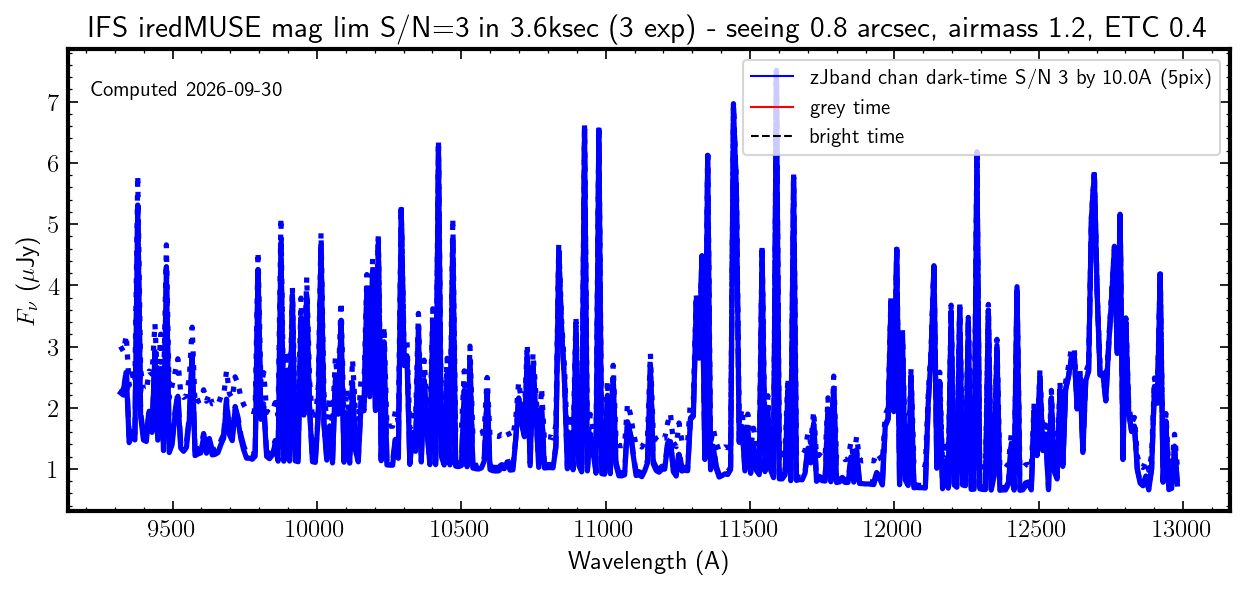

In [166]:
fig,ax = plt.subplots(1,1,figsize=(10,4))
labs = []
for d,c in zip(ifs_psmag[0]['dlim'], ['blue', 'red', 'orange']):
    lab = f"{d['chan']} chan dark-time S/N {snr} by {d['dr']:.1f}A ({d['pixspec']}pix)"
    labs.append(lab)
    muJy=10**((23.9-np.array(d['lmag']))/2.5)
    ax.plot(d['waves'], muJy, color=c, ls='-')
for d,c in zip(ifs_psmag[1]['dlim'], ['blue', 'red', 'orange']):
    muJy=10**((23.9-np.array(d['lmag']))/2.5)
    ax.plot(d['waves'], muJy, color=c, ls='--')
for d,c in zip(ifs_psmag[2]['dlim'], ['blue', 'red', 'orange']):
    muJy=10**((23.9-np.array(d['lmag']))/2.5)
    ax.plot(d['waves'], muJy, color=c, ls=':')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel(r'$F_{\nu}$ ($\mu$Jy)')
see = 'GLAO' if full_obs['GLAO'] else f"seeing {ob['seeing']} arcsec"
integ = full_obs['NDIT']*full_obs['DIT']/1000
snr_req=full_obs['SNR_REQ']
ax.set_title(f"IFS {instru.name} mag lim S/N={snr_req} in {integ:.1f}ksec ({full_obs['NDIT']} exp) - {see}, airmass {full_obs['AM']}, ETC {__version__}");
ax.grid()
custom_lines = [Line2D([0], [0], color='blue', lw=1),
                Line2D([0], [0], color='red', lw=1),
                Line2D([0], [0], color='black', ls='--', lw=1),
                Line2D([0], [0], color='black', ls=':', lw=1),
               ]
labs.append(f"grey time")
labs.append(f"bright time")
ax.legend(custom_lines, labs, fontsize=10,loc=1)
today = datetime.now().strftime("%Y-%m-%d")
ax.text(0.02, 0.90, f"Computed {today}", transform=ax.transAxes, size=10)

In [167]:
today = datetime.now().strftime("%Y-%m-%d")
outfig = os.path.join(path_to_images,f"{today}_{instru.name}_IFS_limiting_Jy.jpg")
fig.savefig(outfig, bbox_inches='tight')
print(f"Saved file {outfig}")

outres = os.path.join(path_to_images,f"{today}_{instru.name}_IFS_limiting_Jy.json")
with open(outres, "w") as f:
    json.dump(ifs_psmag, f, indent=2)
print(f"Saved file {outres}")

Saved file /home/nbouche/Python_git/pyetc_iredmuse/images/2026-09-30_iredMUSE_IFS_limiting_Jy.jpg
Saved file /home/nbouche/Python_git/pyetc_iredmuse/images/2026-09-30_iredMUSE_IFS_limiting_Jy.json


Text(0.02, 0.9, 'Computed 2026-09-30')

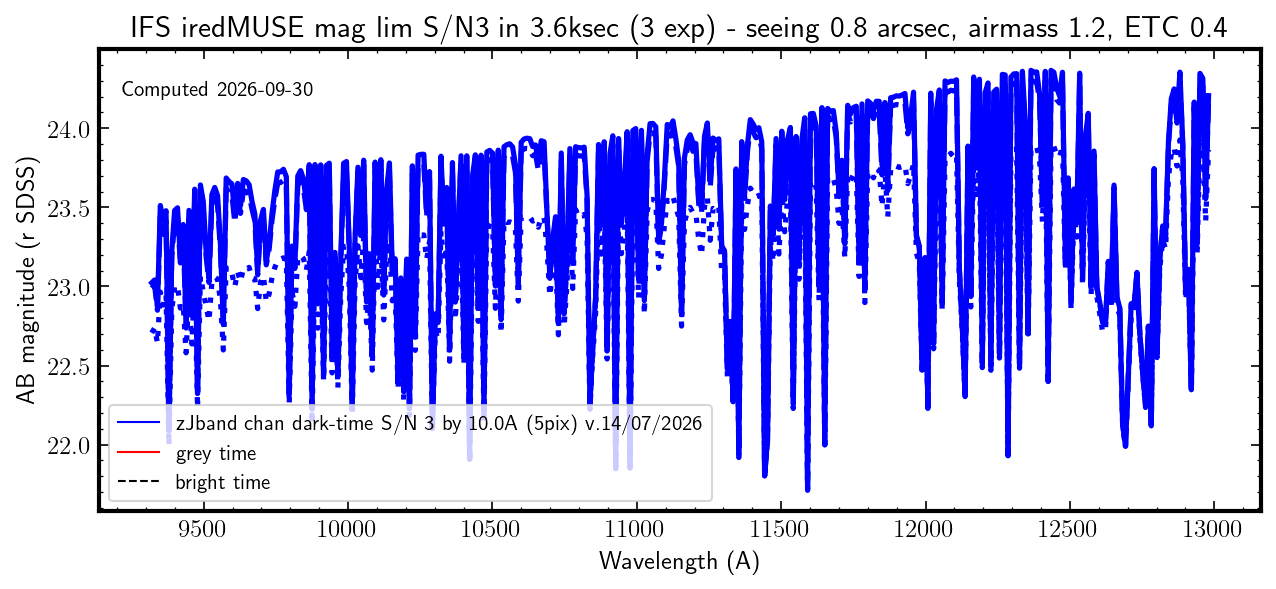

In [168]:
fig,ax = plt.subplots(1,1,figsize=(10,4))
labs = []
for d,c in zip(ifs_psmag[0]['dlim'], ['blue', 'red', 'orange']):
    lab = f"{d['chan']} chan dark-time S/N {snr} by {d['dr']:.1f}A ({d['pixspec']}pix) v.{d['version']}"
    labs.append(lab)
    ax.plot(d['waves'], d['lmag'], color=c, ls='-')
for d,c in zip(ifs_psmag[1]['dlim'], ['blue', 'red', 'orange']):
    ax.plot(d['waves'], d['lmag'], color=c, ls='--')
for d,c in zip(ifs_psmag[2]['dlim'], ['blue', 'red', 'orange']):
    ax.plot(d['waves'], d['lmag'], color=c, ls=':')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('AB magnitude (r SDSS)')
see = 'GLAO' if full_obs['GLAO'] else f"seeing {ob['seeing']} arcsec"
integ_ks = full_obs['NDIT']*full_obs['DIT']/1000
integ_sec = full_obs['NDIT']*full_obs['DIT'] 

snr_req=full_obs['SNR_REQ']
ax.set_title(f"IFS {instru.name} mag lim S/N{snr_req} in {integ_ks:.1f}ksec ({full_obs['NDIT']} exp) - {see}, airmass {full_obs['AM']}, ETC {__version__}");
ax.grid()
custom_lines = [Line2D([0], [0], color='blue', lw=1),
                Line2D([0], [0], color='red', lw=1),
                Line2D([0], [0], color='black', ls='--', lw=1),
                Line2D([0], [0], color='black', ls=':', lw=1),
               ]
labs.append(f"grey time")
labs.append(f"bright time")
ax.legend(custom_lines, labs, fontsize=10)
today = datetime.now().strftime("%Y-%m-%d")
ax.text(0.02, 0.90, f"Computed {today}", transform=ax.transAxes, size=10)

In [169]:
today = datetime.now().strftime("%Y-%m-%d")
outfig = os.path.join(path_to_images,f"{today}_{instru.name}_IFS_limiting_mag.jpg")
fig.savefig(outfig, bbox_inches='tight')
print(f"Saved file {outfig}")

outres = os.path.join(path_to_images,f"{today}_{instru.name}_IFS_limiting_mag.json")
with open(outres, "w") as f:
    json.dump(ifs_psmag, f, indent=2)
print(f"Saved file {outres}")

Saved file /home/nbouche/Python_git/pyetc_iredmuse/images/2026-09-30_iredMUSE_IFS_limiting_mag.jpg
Saved file /home/nbouche/Python_git/pyetc_iredmuse/images/2026-09-30_iredMUSE_IFS_limiting_mag.json


# 8. Compute IFS surface brightness limiting flux

In [170]:
def maglim_ifs_sb(full_obs, lbda, snr, mags, dmag=0.1, dsnr=0.1):
    mag = brentq(zeromag_ifs_sb, mags[0], mags[1], xtol=dsnr, args=(snr, full_obs, lbda))
    return mag
def zeromag_ifs_sb(mag, snr0, full_obs, lbda, inst=instru):
    full_obs['OBJ_MAG'] = mag
    con, ob, spe, im, spe_input = inst.build_obs_full(full_obs)
    res = inst.snr_at_wave(con, im, spe, lbda)
    return res['snr_aperture']-snr0

In [171]:
full_obs = common_obs | ifs_obs_sb    
mags = [10,30]
snr = full_obs["SNR_REQ"]
ifs_sb = []
for fli in [0,0.5,1]:
    print(f"Moon : {fli}")
    dm = dict(fli=fli, ins='ifs')
    full_obs["FLI"] = fli
    dlim = []
    for ch in ifs_channels:
        full_obs['CH'] = ch
        con, ob, spe, im, spe_input = instru.build_obs_full(full_obs)
        dr,lsf,l1,l2,dl,ins = get_specinfo(full_obs)
        integ_hr = full_obs['NDIT']*full_obs['DIT']/3600
        integ_sec = full_obs['NDIT']*full_obs['DIT']
        
        print(f"Instrument {full_obs['INS']} Channel {full_obs['CH']} Version {ins['version']}")
        print(f"Limiting magnitude for S/N = {snr} by resolving element in {integ_hr:.2f} hour(s) ({integ_sec} sec) ({full_obs['NDIT']} exp)")
        print(f"Resolving element {dr} A ({full_obs['COADD_WL']} pix) LSF {lsf} A")
        nwaves = int(((l2-l1)/dr)/2)
        waves = np.linspace(l1+20,l2-20,nwaves)
        lmag = []
        for lbda in tqdm(waves):  
            try:
                mag = maglim_ifs_sb(full_obs, lbda, snr, mags)
            except:
                mag = maglim_ifs_sb(full_obs, lbda, snr, mags=[10,30])
            #print(f"lbda {lbda:.1f} mag {mag:.2f} niter {niter}")
            lmag.append(mag)
            mags = [mag-0.5,mag+0.5]
        dlim.append(dict(chan=ch, waves=waves.tolist(), lmag=lmag, snr=snr, integ=integ, nexp=full_obs['NDIT'], dr=dr, dl=dl, 
                            lbda=(l1,l2), lsf=lsf, pixspec=full_obs['COADD_WL'], version=ins['version']))
    dm['dlim'] = dlim
    ifs_sb.append(dm)

Moon : 0
Instrument ifs Channel zJband Version 14/07/2026
Limiting magnitude for S/N = 3 by resolving element in 1.00 hour(s) (3600 sec) (3 exp)
Resolving element 10.0 A (5 pix) LSF 4.4 A


  0%|          | 0/185 [00:00<?, ?it/s]

Moon : 0.5
Instrument ifs Channel zJband Version 14/07/2026
Limiting magnitude for S/N = 3 by resolving element in 1.00 hour(s) (3600 sec) (3 exp)
Resolving element 10.0 A (5 pix) LSF 4.4 A


  0%|          | 0/185 [00:00<?, ?it/s]

Moon : 1
Instrument ifs Channel zJband Version 14/07/2026
Limiting magnitude for S/N = 3 by resolving element in 1.00 hour(s) (3600 sec) (3 exp)
Resolving element 10.0 A (5 pix) LSF 4.4 A


  0%|          | 0/185 [00:00<?, ?it/s]

Text(0.02, 0.9, 'Computed 2026-09-30')

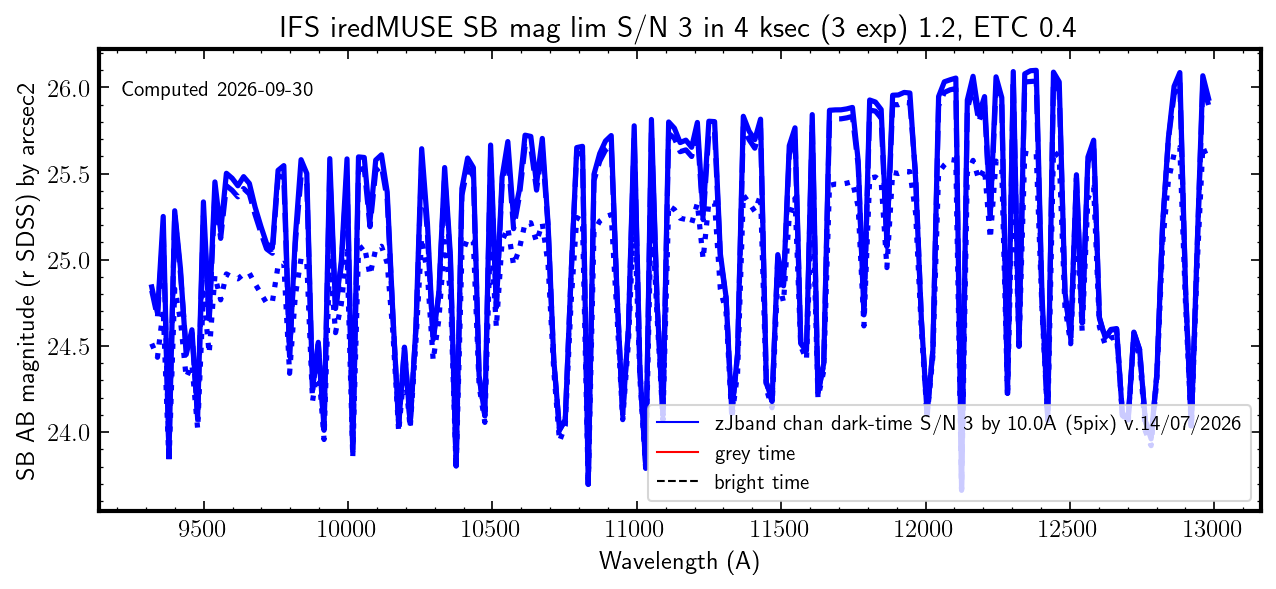

In [172]:
fig,ax = plt.subplots(1,1,figsize=(10,4))
labs = []
for d,c in zip(ifs_sb[0]['dlim'], ['blue','red']):
    lab = f"{d['chan']} chan dark-time S/N {snr} by {d['dr']:.1f}A ({d['pixspec']}pix) v.{d['version']}"
    labs.append(lab)
    ax.plot(d['waves'], d['lmag'], color=c, ls='-')
for d,c in zip(ifs_sb[1]['dlim'], ['blue','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls='--')
for d,c in zip(ifs_sb[2]['dlim'], ['blue','red']):
    ax.plot(d['waves'], d['lmag'], color=c, ls=':')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('SB AB magnitude (r SDSS) by arcsec2')
integ = full_obs['NDIT']*full_obs['DIT']/1000
snr_req=full_obs['SNR_REQ']
ax.set_title(f"IFS {instru.name} SB mag lim S/N {snr_req} in {integ:.0f} ksec ({full_obs['NDIT']} exp) {full_obs['AM']}, ETC {__version__}");
ax.grid()
custom_lines = [Line2D([0], [0], color='blue', lw=1),
                Line2D([0], [0], color='red', lw=1),
                Line2D([0], [0], color='black', ls='--', lw=1),
                Line2D([0], [0], color='black', ls=':', lw=1),
               ]
labs.append(f"grey time")
labs.append(f"bright time")
ax.legend(custom_lines, labs, fontsize=10)
today = datetime.now().strftime("%Y-%m-%d")
ax.text(0.02, 0.90, f"Computed {today}", transform=ax.transAxes, size=10)

In [173]:
today = datetime.now().strftime("%Y-%m-%d")
outfig = os.path.join(path_to_images,f"{today}_{instru.name}_IFS_SBlimiting_mag.jpg")
fig.savefig(outfig, bbox_inches='tight')
print(f"Saved file {outfig}")

outres = os.path.join(path_to_images,f"{today}_{instru.name}_IFS_SBlimiting_mag.json")
with open(outres, "w") as f:
    json.dump(ifs_sb, f, indent=2)
print(f"Saved file {outres}")

Saved file /home/nbouche/Python_git/pyetc_iredmuse/images/2026-09-30_iredMUSE_IFS_SBlimiting_mag.jpg
Saved file /home/nbouche/Python_git/pyetc_iredmuse/images/2026-09-30_iredMUSE_IFS_SBlimiting_mag.json


Text(0.02, 0.9, 'Computed 2026-09-30')

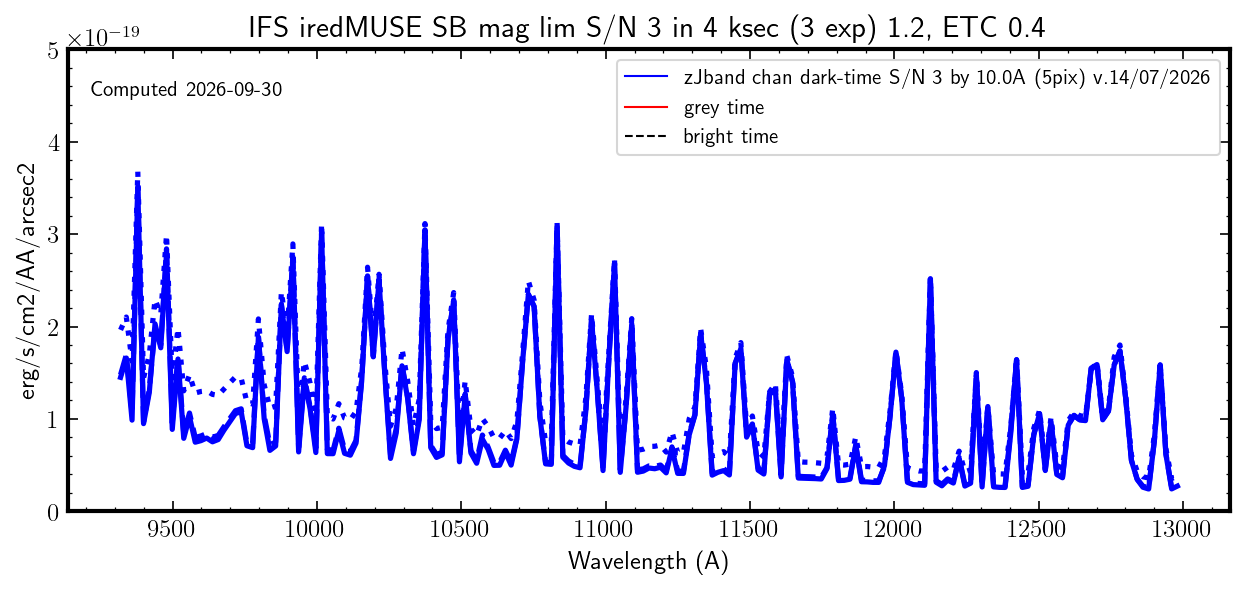

In [174]:
fig,ax = plt.subplots(1,1,figsize=(10,4))
labs = []
for d,c in zip(ifs_sb[0]['dlim'], ['blue','red', 'orange']):
    lab = f"{d['chan']} chan dark-time S/N {snr} by {d['dr']:.1f}A ({d['pixspec']}pix) v.{d['version']}"
    labs.append(lab)
    muJy=10**((23.9-np.array(d['lmag']))/2.5)
    flam=muJy*3e18/np.array(d['waves'])**2*1e-23*1e-6
    ax.plot(d['waves'], flam, color=c, ls='-')
for d,c in zip(ifs_sb[1]['dlim'], ['blue','red']):
    muJy=10**((23.9-np.array(d['lmag']))/2.5)
    flam=muJy*3e18/np.array(d['waves'])**2*1e-23*1e-6
    ax.plot(d['waves'], flam, color=c, ls='--')
for d,c in zip(ifs_sb[2]['dlim'], ['blue','red', 'orange']):
    muJy=10**((23.9-np.array(d['lmag']))/2.5)
    flam=muJy*3e18/np.array(d['waves'])**2*1e-23*1e-6
    ax.plot(d['waves'], flam, color=c, ls=':')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('erg/s/cm2/AA/arcsec2')
integ = full_obs['NDIT']*full_obs['DIT']/1000
snr_req=full_obs['SNR_REQ']
ax.set_title(f"IFS {instru.name} SB mag lim S/N {snr_req} in {integ:.0f} ksec ({full_obs['NDIT']} exp) {full_obs['AM']}, ETC {__version__}");
ax.grid()
custom_lines = [Line2D([0], [0], color='blue', lw=1),
                Line2D([0], [0], color='red', lw=1),
                Line2D([0], [0], color='black', ls='--', lw=1),
                Line2D([0], [0], color='black', ls=':', lw=1),
               ]
labs.append(f"grey time")
labs.append(f"bright time")
ax.legend(custom_lines, labs, fontsize=10)
ax.set_ylim([0,0.5e-18])
today = datetime.now().strftime("%Y-%m-%d")
ax.text(0.02, 0.90, f"Computed {today}", transform=ax.transAxes, size=10)

In [175]:
today = datetime.now().strftime("%Y-%m-%d")
outfig = os.path.join(path_to_images,f"{today}_{instru.name}_IFS_SBlimiting_cgs.jpg")
fig.savefig(outfig, bbox_inches='tight')
print(f"Saved file {outfig}")

outres = os.path.join(path_to_images,f"{today}_{instru.name}_IFS_SBlimiting_cgs.json")
with open(outres, "w") as f:
    json.dump(ifs_sb, f, indent=2)
print(f"Saved file {outres}")

Saved file /home/nbouche/Python_git/pyetc_iredmuse/images/2026-09-30_iredMUSE_IFS_SBlimiting_cgs.jpg
Saved file /home/nbouche/Python_git/pyetc_iredmuse/images/2026-09-30_iredMUSE_IFS_SBlimiting_cgs.json


# 9. Compute IFS limiting emission flux

In [195]:
def snr_sum(signal, noise):
    signal = signal.data
    noise = noise.data
    variance = noise**2
    #mask |= variance > 0
    #s = signal[mask]
    #v = variance[mask]
    #w = 1.0/v
    #snr = np.sum(s) / np.sqrt(np.sum(v))
    snr = np.nansum(signal**2/noise**2)**0.5 #np.sum(Signal**2 / error**2)**0.5
    return snr

In [196]:
def fluxlim_ifs(full_obs, lbda, snr, fluxes, dmag=0.1, dsnr=0.1):
    flux = brentq(zeroflux_ifs, fluxes[0], fluxes[1], xtol=dsnr, args=(snr, full_obs, lbda))
    return flux*1.e-20
def zeroflux_ifs(flux, snr0, full_obs, lbda, inst=instru):
    full_obs['SEL_FLUX'] = flux*1.e-20
    full_obs['SEL_CWAV'] = lbda
    con, ob, spe, im, spe_input = inst.build_obs_full(full_obs)
    res = inst.snr_from_source(con, im, spe)
    spsignal = res['spec']['nph_source']
    spnoise = res['spec']['noise']['tot']
    snrmax = snr_sum(spsignal,spnoise)
    #print(flux,snrmax)
    return snrmax-snr0

In [202]:
full_obs = common_obs | ifs_obs_psl   
snr = full_obs["SNR_REQ"]
fluxes = [1,100000]
ifs_line = []
for fli in [0,0.5,1]:
    print(f"Moon : {fli}")
    dm = dict(fli=fli, ins='ifs')
    full_obs["FLI"] = fli
    dlim = []
    for ch in ifs_channels:
        full_obs['CH'] = ch
        dr,lsf,l1,l2,dl,ins = get_specinfo(full_obs)
        integ_hr = full_obs['NDIT']*full_obs['DIT']/3600
        print(f"Instrument {full_obs['INS']} Channel {full_obs['CH']} Version {ins['version']}")
        print(f"Limiting magnitude for S/N = {snr} by resolving element in {integ_hr:.2f} hour(s) ({full_obs['NDIT']} exp)")
        print(f"Resolving element {dr} A ({full_obs['COADD_WL']} pix) LSF {lsf} A")
        nwaves = int(((l2-l1)/dr)/1)
        waves = np.linspace(l1+20,l2-20,nwaves)
        lmag = []
        for lbda in tqdm(waves): 
            try:
                flux = fluxlim_ifs(full_obs, lbda, snr, fluxes)
            except:
                flux = fluxlim_ifs(full_obs, lbda, snr, fluxes=[1,100000])
            #print(f"lbda {lbda:.1f} mag {mag:.2f} niter {niter}")
            lmag.append(flux)
            fluxes = [flux*1.e20/2,flux*1.e20*2]
            #print (flux,fluxes)
        dlim.append(dict(chan=ch, waves=waves.tolist(), lmag=lmag, snr=snr, integ=integ, nexp=full_obs['NDIT'], dr=dr, dl=dl, 
                            lbda=(l1,l2), lsf=lsf, fwhm=full_obs['SEL_FWHM'], pixspec=full_obs['COADD_WL'], version=ins['version']))
    dm['dlim'] = dlim
    ifs_line.append(dm)

Moon : 0
Instrument ifs Channel zJband Version 14/07/2026
Limiting magnitude for S/N = 3 by resolving element in 1.00 hour(s) (3 exp)
Resolving element 4.0 A (2 pix) LSF 4.4 A


  0%|          | 0/92 [00:00<?, ?it/s]

[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 5 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9360.2 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9360.2 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9360.2 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9360.2 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9360.2 AA, initial guess=4)

  0%|          | 0/92 [00:00<?, ?it/s]

[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 5 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9360.2 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9360.2 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9360.2 AA, initial guess=4)

  0%|          | 0/92 [00:00<?, ?it/s]

[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 5 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9320.0 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9360.2 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9360.2 AA, initial guess=4)
[INFO] Sky taken from static files
[INFO] Optimal coadd: 4 (at 9360.2 AA, initial guess=4)

Text(0.02, 0.9, 'Computed 2026-09-30')

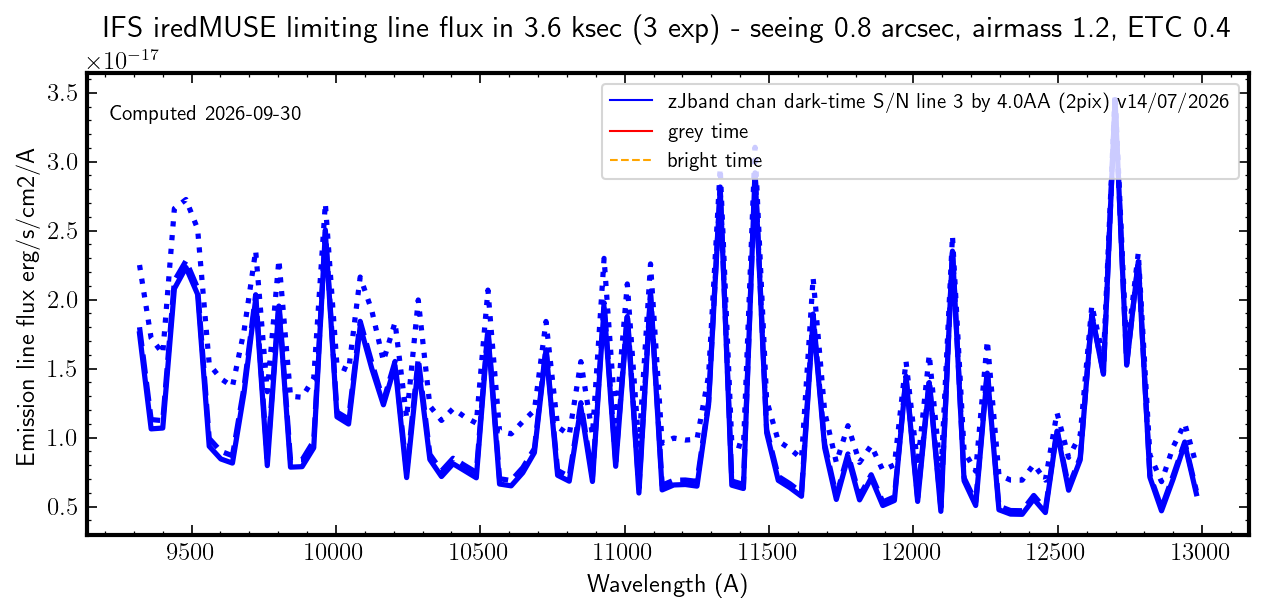

In [203]:
fig,ax = plt.subplots(1,1,figsize=(10,4))
labs = []
for d,c in zip(ifs_line[0]['dlim'], ['blue', 'red', 'orange']):
    lab = f"{d['chan']} chan dark-time S/N line {snr} by {d['dr']}AA ({d['pixspec']}pix) v{d['version']} "
    labs.append(lab)
    ax.plot(d['waves'], d['lmag'], color=c, ls='-')
for d,c in zip(ifs_line[1]['dlim'], ['blue', 'red', 'orange']):
    ax.plot(d['waves'], d['lmag'], color=c, ls='--')
for d,c in zip(ifs_line[2]['dlim'], ['blue', 'red', 'orange']):
    ax.plot(d['waves'], d['lmag'], color=c, ls=':')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('Emission line flux erg/s/cm2/A')
see = 'GLAO' if full_obs['GLAO'] else f"seeing {ob['seeing']} arcsec"

integ = full_obs['NDIT']*full_obs['DIT']/1000
ax.set_title(f"IFS {instru.name} limiting line flux in {integ:.1f} ksec ({full_obs['NDIT']} exp) - {see}, airmass {full_obs['AM']}, ETC {__version__}");
ax.grid()
custom_lines = [Line2D([0], [0], color='blue', lw=1),
                Line2D([0], [0], color='red', lw=1),
                Line2D([0], [0], color='orange', ls='--', lw=1),
                Line2D([0], [0], color='black', ls=':', lw=1),
               ]
labs.append(f"grey time")
labs.append(f"bright time")
ax.legend(custom_lines, labs, fontsize=10,loc=1)
today = datetime.now().strftime("%Y-%m-%d")
ax.text(0.02, 0.90, f"Computed {today}", transform=ax.transAxes, size=10)

In [204]:
today = datetime.now().strftime("%Y-%m-%d")
outfig = os.path.join(path_to_images,f"{today}_{instru.name}_IFS_limiting_Lineflux.jpg")
fig.savefig(outfig, bbox_inches='tight')
print(f"Saved file {outfig}")

outres = os.path.join(path_to_images,f"{today}_{instru.name}_IFS_limiting_Lineflux.json")
with open(outres, "w") as f:
    json.dump(ifs_line, f, indent=2)
print(f"Saved file {outres}")

Saved file /home/nbouche/Python_git/pyetc_iredmuse/images/2026-09-30_iredMUSE_IFS_limiting_Lineflux.jpg
Saved file /home/nbouche/Python_git/pyetc_iredmuse/images/2026-09-30_iredMUSE_IFS_limiting_Lineflux.json


# Signal to noise for line

In [113]:
x=np.arange(-15,15,0.1)
def gauss(x,A,x0,s=1):
    return A*np.exp(-(x-x0)**2/s**2)

In [114]:
Signal=gauss(x,2,x0=0,s=1)
Variance=Signal

#simulated  OH line
e1=gauss(x,10,-12,s=1)
e2=gauss(x,10,-5,s=1)
e3=gauss(x,20,7.5,s=1)
e4=gauss(x,20,12,s=1)

error=e1+e2+e3+e4+Variance**0.5+0.5

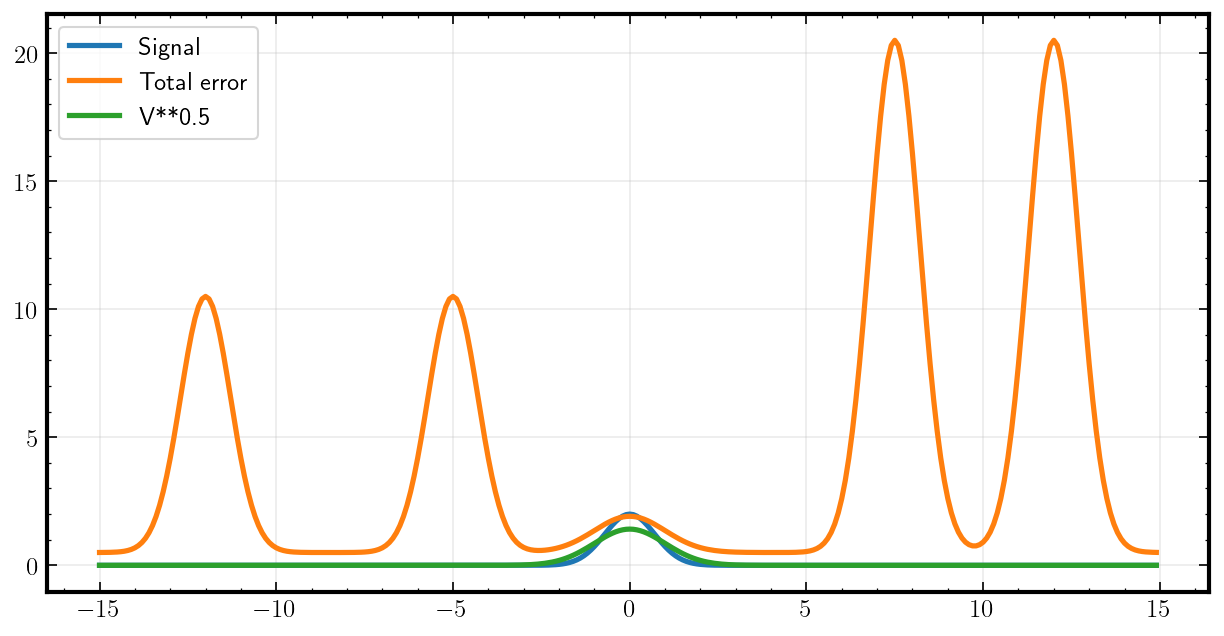

In [115]:
plt.plot(x,Signal,label='Signal')
plt.plot(x,error,label='Total error')
plt.plot(x,Variance**0.5,label='V**0.5')
plt.legend()

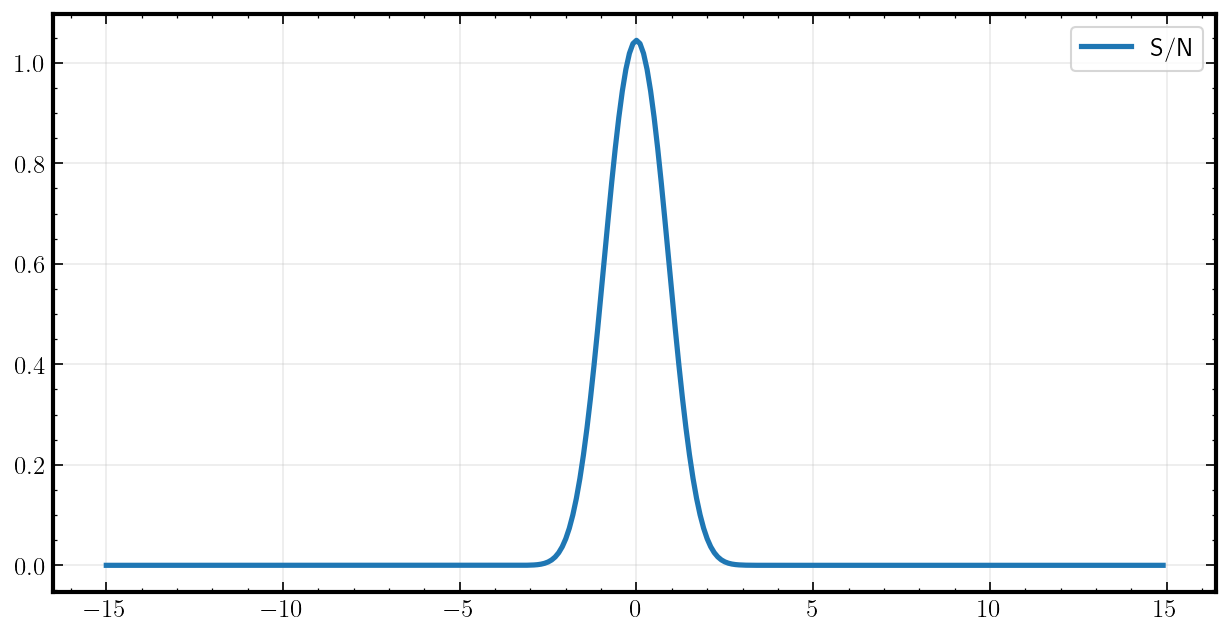

In [116]:
plt.plot(x,Signal/error,label='S/N')
plt.legend()

## Total SNR

$ S = \sum f_i $ Signal

$ V= \sigma_i^2 = S $ variance

$S/N = \sum f_i /\sqrt{ \sum V_i}$

In [117]:
SNR_i=Signal/error

SNR=np.sum(Signal) / np.sqrt(np.sum(error**2))
print(SNR)

SNR=np.sum(Signal) / np.sqrt(np.sum(Variance))
print(SNR)


0.30238766786334953
5.9539127486141785


## Mean SNR
### Gaussian weights

In [125]:
w=gauss(x,1,0,1)
w=w/np.sum(w)

snr = np.sum(SNR_i * w) / np.sum(w)
print("Mean SNR",snr)

Mean SNR 0.8123541446254088


# weighted SNR The weighted S/N formula


$ S/N = \frac{\sum w_i f_i}{\sqrt{\sum w_i^2 \sigma_i^2}}$

### error weights

$w_i = V^{-0.5} = 1/ \sigma_i$

$ S/N = \frac{\sum  f_i / \sigma_i}{\sqrt{\sum \sigma_i^{-2} \sigma_i^2}}$

$ S/N = \frac{\sum f_i / \sigma_i}{\sqrt{N}}$ = mean SNR

In [188]:

w=1/error
snr = np.sum(Signal 
             * w) / np.sum(w**2 * error**2)**0.5
print("Total mean SNR",snr)


print(np.sum(Signal/error)/np.sqrt(len(w)))

Total mean SNR 1.2905208439856646
1.2905208439856646


### Gaussian weights

for weights $w_i = g_i $ 

$ S/N = \frac{\sum g_i  f_i}{\sqrt{\sum g_i^2  \sigma_i^2}}$



In [189]:
g=gauss(x,1,0,1)
g=g/np.sum(w)

snr = np.sum(Signal * g) / np.sum(g**2 * error**2)**0.5
print("Total SNR {} with gaussian filter".format(snr))

Total SNR 3.9907006439546957 with gaussian filter


### Optimal extraction

for weights $w_i = f_i / \sigma_i^2$  

$ S/N = \frac{\sum f_i / \sigma_i^2 * f_i}{\sqrt{\sum f_i^2 / \sigma_i^4 \sigma_i^2}}$

$ S/N = \frac{\sum f_i / \sigma_i^2 * f_i}{\sqrt{\sum f_i^2 / \sigma_i^2}}$

$ S/N = \sqrt{\sum f_i^2 / \sigma_i^2  }$




In [190]:
w=gauss(x,1,0,1)/error**2
w=w/np.sum(w)


snr = np.sum(Signal * w) / np.sum(w**2 * error**2)**0.5
print("Total SNR {} with optimal Gaussian filtering".format(snr))


w=Signal/error**2


snr = np.sum(Signal * w) / np.sum(w**2 * error**2)**0.5
print("Total SNR {} with optimal weights".format(snr))


Total SNR 4.104382351753742 with optimal Gaussian filtering
Total SNR 4.104382351753742 with optimal weights


In [191]:
#but this is wrong  because
w=Signal/Variance # is 1.0 


snr = np.sum(Signal * w) / np.sum(w**2 * error**2)**0.5
print("Total SNR {} with optimal weights".format(snr))


Total SNR 0.30238766786334953 with optimal weights


In [192]:
snr = np.sum(Signal**2 / error**2)**0.5
print("Total SNR {} with match filtering".format(snr))

Total SNR 4.104382351753742 with match filtering
